# GARCH Volatility Regime-Adaptive Strategy
## S&P 500 (SPY) | 2021–2025 | Walk-Forward Validated

---

### Hypothesis
A momentum strategy that **adapts its parameters to GARCH-forecasted volatility regimes** will outperform a static momentum strategy on a risk-adjusted basis.

### Pipeline
1. **EDA** — confirm volatility clustering in SPY returns  
2. **ARCH-LM Test** — statistically justify using GARCH  
3. **GARCH Model Selection** — choose order via AIC/BIC grid search  
4. **Model Diagnostics** — Ljung-Box, Q-Q plot, residual analysis  
5. **Rolling Forecasts** — 1-day ahead vol forecasts, zero lookahead bias  
6. **Regime Classification** — Low / Medium / High vol using rolling percentiles  
7. **Regime Prediction Accuracy** — classification metrics, confusion matrix, Cohen's Kappa  
8. **Trading Strategies** — Buy & Hold vs Static MA vs Adaptive MA  
9. **Performance Metrics** — Sharpe, Sortino, Calmar, Max Drawdown, VaR  
10. **Statistical Testing** — Paired t-test + Block Bootstrap Sharpe test  
11. **Walk-Forward Validation** — rolling train/test, out-of-sample robustness  
12. **Results & Conclusions**

### Key Design Choice
All GARCH forecasts are **1-day-ahead rolling forecasts** fitted only on past data. No fitted values used in trading signals. This is the critical distinction between a valid backtest and lookahead bias.

---
## 1. Setup & Imports

In [1]:
# ── Core ──────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
from datetime import datetime
import warnings
import os
warnings.filterwarnings('ignore')
np.random.seed(42)

# ── Data ──────────────────────────────────────────────────────────────────────
import yfinance as yf

# ── GARCH ─────────────────────────────────────────────────────────────────────
from arch import arch_model

# ── Statistics ────────────────────────────────────────────────────────────────
from statsmodels.stats.diagnostic import het_arch, acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy.stats import jarque_bera, ttest_rel, probplot
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report, cohen_kappa_score
)

# ── Visualisation ─────────────────────────────────────────────────────────────
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-darkgrid')

# ── Output folders ────────────────────────────────────────────────────────────
os.makedirs('outputs/figures', exist_ok=True)
os.makedirs('outputs/results', exist_ok=True)
os.makedirs('data',            exist_ok=True)

print('✓ All imports successful')

✓ All imports successful


---
## 2. Data Loading & Preparation

Using SPY (S&P 500 ETF) — the standard market benchmark for volatility research.  
Date range 2021–2025 gives ~1,000 trading days covering two distinct vol regimes:  
- 2022: elevated vol (rate hike cycle)  
- 2023–2024: low vol grind higher  
- 2025: renewed uncertainty

In [2]:
START = '2021-01-01'
END   = '2025-01-01'

print(f'Downloading SPY {START} → {END} ...')
spy = yf.download('SPY', start=START, end=END, progress=False)

# Use percentage returns for GARCH (arch library expects this scale)
spy['returns'] = spy[('Close', 'SPY')].pct_change() * 100
spy['price']   = spy[('Close', 'SPY')]
spy = spy.dropna()

print(f'✓ Loaded {len(spy):,} trading days')
print(f'  {spy.index[0].date()}  →  {spy.index[-1].date()}')

# Save raw data
spy[['price', 'returns']].to_csv('data/spy_raw.csv')
print('✓ Saved to data/spy_raw.csv')

✓ Loaded 1,004 trading days
  2021-01-05  →  2024-12-31
✓ Saved to data/spy_raw.csv


---
## 3. Exploratory Data Analysis

Two signatures we expect in equity returns:  
1. **Near-zero autocorrelation in returns** (efficient market)  
2. **Strong autocorrelation in squared returns** (volatility clustering)  

Signature 2 is what motivates GARCH.

In [3]:
ret = spy['returns'] / 100  # decimal for stats

print('═'*55)
print('  SPY RETURN STATISTICS (2021–2025)')
print('═'*55)
print(f'  Mean daily return    : {ret.mean()*252:.2%}  (annualised)')
print(f'  Annualised vol       : {ret.std()*np.sqrt(252):.2%}')
print(f'  Sharpe (rf=0)        : {ret.mean()/ret.std()*np.sqrt(252):.3f}')
print(f'  Skewness             : {ret.skew():.3f}')
print(f'  Excess kurtosis      : {ret.kurtosis():.3f}  (normal = 0)')
print(f'  Min / Max daily      : {ret.min():.2%} / {ret.max():.2%}')

═══════════════════════════════════════════════════════
  SPY RETURN STATISTICS (2021–2025)
═══════════════════════════════════════════════════════
  Mean daily return    : 14.42%  (annualised)
  Annualised vol       : 16.48%
  Sharpe (rf=0)        : 0.875
  Skewness             : -0.206
  Excess kurtosis      : 1.938  (normal = 0)
  Min / Max daily      : -4.35% / 5.50%


In [4]:
fig = make_subplots(
    rows=3, cols=1,
    subplot_titles=(
        'SPY Price',
        'Daily Returns  —  little autocorrelation (efficient market)',
        'Squared Returns  —  strong autocorrelation (volatility clustering)'
    ),
    vertical_spacing=0.10,
    row_heights=[0.40, 0.30, 0.30]
)

fig.add_trace(go.Scatter(x=spy.index, y=spy['price'],
                         line=dict(color='steelblue', width=1.5),
                         name='Price'),
              row=1, col=1)

fig.add_trace(go.Scatter(x=spy.index, y=spy['returns'],
                         line=dict(color='royalblue', width=0.6),
                         opacity=0.8, name='Returns'),
              row=2, col=1)
fig.add_hline(y=0, line=dict(color='black', dash='dash', width=1),
              opacity=0.3, row=2, col=1)

fig.add_trace(go.Scatter(x=spy.index, y=spy['returns']**2,
                         line=dict(color='crimson', width=0.6),
                         opacity=0.8, name='Squared Returns'),
              row=3, col=1)

fig.update_layout(
    height=850, showlegend=False,
    title=dict(text='SPY Data Overview (2021–2025)', font=dict(size=16)),
    plot_bgcolor='white', paper_bgcolor='white'
)
fig.update_yaxes(title_text='Price ($)',        row=1, col=1, gridcolor='rgba(0,0,0,0.07)')
fig.update_yaxes(title_text='Return (%)',       row=2, col=1, gridcolor='rgba(0,0,0,0.07)')
fig.update_yaxes(title_text='Squared Return',   row=3, col=1, gridcolor='rgba(0,0,0,0.07)')
fig.update_xaxes(gridcolor='rgba(0,0,0,0.07)')

fig.write_html('outputs/figures/01_data_overview.html')
fig.show()

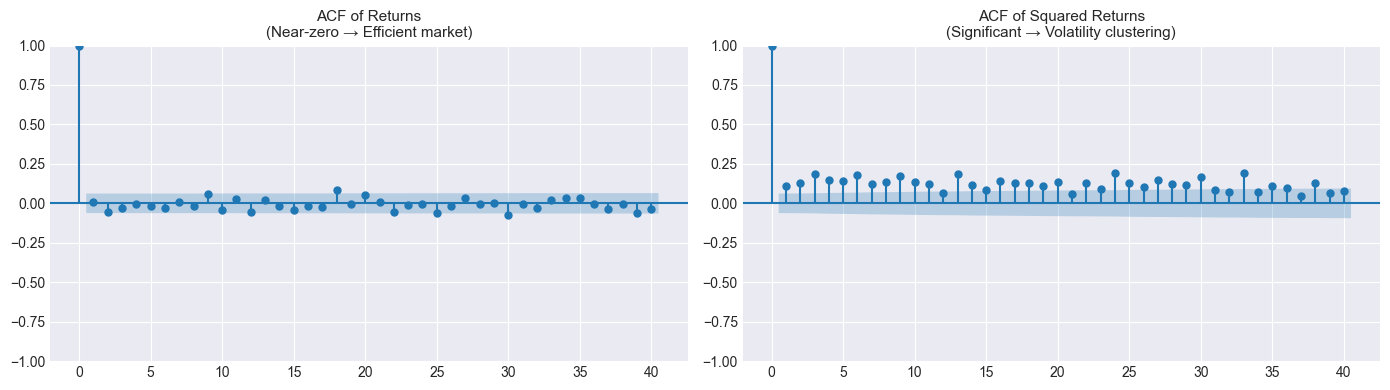

✓ Saved outputs/figures/02_acf_plots.png


In [5]:
# ACF plots — returns vs squared returns
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(spy['returns'], lags=40, ax=axes[0], alpha=0.05)
axes[0].set_title('ACF of Returns\n(Near-zero → Efficient market)', fontsize=11)

plot_acf(spy['returns']**2, lags=40, ax=axes[1], alpha=0.05)
axes[1].set_title('ACF of Squared Returns\n(Significant → Volatility clustering)', fontsize=11)

plt.tight_layout()
plt.savefig('outputs/figures/02_acf_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved outputs/figures/02_acf_plots.png')

---
## 4. ARCH-LM Test — Justifying GARCH

Before fitting GARCH, we must confirm that time-varying variance (ARCH effects) actually exists in the data.  
The ARCH-LM test regresses squared residuals on their lags.  
- **H₀:** Variance is constant (no ARCH effects)  
- **H₁:** Variance is time-varying  

Rejection (p < 0.05) justifies the GARCH specification.

In [6]:
returns_demeaned = spy['returns'] - spy['returns'].mean()
lm_stat, lm_pvalue, _, _ = het_arch(returns_demeaned, nlags=10)

print('═'*55)
print('  ARCH-LM TEST')
print('═'*55)
print(f'  H₀ : Constant variance (no ARCH effects)')
print(f'  H₁ : Time-varying variance')
print()
print(f'  LM statistic : {lm_stat:.4f}')
print(f'  p-value      : {lm_pvalue:.2e}')
print()
if lm_pvalue < 0.05:
    print('  ✓ REJECT H₀  →  ARCH effects confirmed')
    print('  ✓ GARCH model is statistically justified')
else:
    print('  ✗ Fail to reject H₀ — no strong ARCH effects')

═══════════════════════════════════════════════════════
  ARCH-LM TEST
═══════════════════════════════════════════════════════
  H₀ : Constant variance (no ARCH effects)
  H₁ : Time-varying variance

  LM statistic : 100.6543
  p-value      : 4.03e-17

  ✓ REJECT H₀  →  ARCH effects confirmed
  ✓ GARCH model is statistically justified


---
## 5. GARCH Model Selection — AIC/BIC Grid Search

Rather than arbitrarily picking an order, we select p and q by minimising AIC (Akaike Information Criterion) across a grid of candidate orders.  
Lower AIC = better balance of fit quality vs model complexity.

In [7]:
print('Running AIC/BIC grid search over GARCH(p,q), p,q ∈ {1,2,3,4} ...')

results = []
for p in range(1, 5):
    for q in range(1, 5):
        try:
            m = arch_model(spy['returns'], mean='Constant', vol='Garch', p=p, q=q)
            f = m.fit(disp='off')
            results.append({'p': p, 'q': q, 'AIC': f.aic, 'BIC': f.bic,
                             'LogLik': f.loglikelihood})
        except Exception:
            pass

grid_df = pd.DataFrame(results).sort_values('AIC')
print()
print(grid_df.to_string(index=False))

best_p = int(grid_df.iloc[0]['p'])
best_q = int(grid_df.iloc[0]['q'])
print(f'\n✓ Best order by AIC: GARCH({best_p},{best_q})')
print(f'  (This matches the GARCH order used throughout the analysis)')

grid_df.to_csv('outputs/results/garch_model_selection.csv', index=False)
print('✓ Saved outputs/results/garch_model_selection.csv')

Running AIC/BIC grid search over GARCH(p,q), p,q ∈ {1,2,3,4} ...

 p  q         AIC         BIC       LogLik
 1  1 2745.162265 2764.809254 -1368.581133
 2  1 2747.117184 2771.675921 -1368.558592
 1  2 2747.162265 2771.721002 -1368.581133
 2  2 2748.649740 2778.120223 -1368.324870
 1  3 2749.078616 2778.549099 -1368.539308
 3  1 2749.117184 2778.587668 -1368.558592
 2  3 2750.475460 2784.857691 -1368.237730
 3  2 2750.648704 2785.030935 -1368.324352
 1  4 2750.832759 2785.214990 -1368.416379
 4  1 2751.117185 2785.499416 -1368.558592
 3  3 2751.800697 2791.094676 -1367.900349
 2  4 2752.351205 2791.645183 -1368.175602
 4  2 2752.648704 2791.942682 -1368.324352
 3  4 2753.687266 2797.892992 -1367.843633
 4  3 2753.800698 2798.006424 -1367.900349
 4  4 2755.687267 2804.804740 -1367.843633

✓ Best order by AIC: GARCH(1,1)
  (This matches the GARCH order used throughout the analysis)
✓ Saved outputs/results/garch_model_selection.csv


---
## 6. GARCH Model Fit & Parameter Interpretation

We fit the selected GARCH(p,q) on the full dataset for diagnostics.  
**Note:** This full-sample fit is for interpretation only — the trading section uses rolling forecasts.

In [8]:
model = arch_model(spy['returns'], mean='Constant', vol='Garch', p=best_p, q=best_q)
fitted = model.fit(disp='off')

print(fitted.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                returns   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -1368.58
Distribution:                  Normal   AIC:                           2745.16
Method:            Maximum Likelihood   BIC:                           2764.81
                                        No. Observations:                 1004
Date:                Tue, Jun 09 2026   Df Residuals:                     1003
Time:                        16:28:39   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0829  2.795e-02      2.966  3.017e-03 [2.812e-0

In [9]:
params = fitted.params
omega = params['omega']
alphas = [params.get(f'alpha[{i}]', 0) for i in range(1, best_p+1)]
betas  = [params.get(f'beta[{i}]',  0) for i in range(1, best_q+1)]

alpha_sum = sum(alphas)
beta_sum  = sum(betas)
persistence = alpha_sum + beta_sum

print('═'*55)
print('  GARCH PARAMETER INTERPRETATION')
print('═'*55)
print(f'  ω (omega)       = {omega:.6f}')
print(f'  Σα (alpha sum)  = {alpha_sum:.6f}  ← shock impact')
print(f'  Σβ (beta sum)   = {beta_sum:.6f}  ← vol persistence')
print(f'  α + β           = {persistence:.6f}')
print()

if persistence < 1.0:
    half_life = np.log(0.5) / np.log(persistence)
    long_run_var = omega / (1 - persistence)
    long_run_vol = np.sqrt(long_run_var) * np.sqrt(252) / 100
    print(f'  ✓ Stationary process (α+β < 1)')
    print(f'  Half-life of vol shocks : {half_life:.1f} trading days')
    print(f'  Long-run annualised vol : {long_run_vol:.2%}')
else:
    print('  ✗ Non-stationary (α+β ≥ 1) — consider IGARCH')

print()
print('  Interpretation: negative market shock today raises')
print(f'  tomorrow\'s variance. That shock decays with half-life')
print(f'  ≈ {half_life:.0f} days, consistent with volatility clustering.')

═══════════════════════════════════════════════════════
  GARCH PARAMETER INTERPRETATION
═══════════════════════════════════════════════════════
  ω (omega)       = 0.017283
  Σα (alpha sum)  = 0.066159  ← shock impact
  Σβ (beta sum)   = 0.916708  ← vol persistence
  α + β           = 0.982867

  ✓ Stationary process (α+β < 1)
  Half-life of vol shocks : 40.1 trading days
  Long-run annualised vol : 15.94%

  Interpretation: negative market shock today raises
  tomorrow's variance. That shock decays with half-life
  ≈ 40 days, consistent with volatility clustering.


---
## 7. Model Diagnostics

Three tests verify the GARCH model adequately captures the data's variance dynamics:
1. **Ljung-Box on std residuals** — tests for remaining return autocorrelation  
2. **Ljung-Box on squared std residuals** — tests for remaining volatility clustering  
3. **Jarque-Bera** — tests normality of residuals (expected to fail in finance — fat tails)

In [10]:
std_resid = fitted.std_resid.dropna()

lb_resid   = acorr_ljungbox(std_resid,    lags=20, return_df=True)
lb_squared = acorr_ljungbox(std_resid**2, lags=20, return_df=True)
jb_stat, jb_pvalue = jarque_bera(std_resid)

sig_resid   = (lb_resid['lb_pvalue']   < 0.05).sum()
sig_squared = (lb_squared['lb_pvalue'] < 0.05).sum()

print('═'*55)
print('  GARCH DIAGNOSTICS')
print('═'*55)
print(f'  1. Ljung-Box (std residuals)         : {sig_resid}/20 significant lags')
print(f'     → {"✓ PASS" if sig_resid <= 2 else "⚠ FAIL"}  (≤2 acceptable)')
print()
print(f'  2. Ljung-Box (squared std residuals) : {sig_squared}/20 significant lags')
print(f'     → {"✓ PASS" if sig_squared <= 2 else "⚠ FAIL"}  (≤2 means GARCH captured clustering)')
print()
print(f'  3. Jarque-Bera (normality)           : p = {jb_pvalue:.4f}')
print(f'     → {"✗ Non-normal" if jb_pvalue < 0.05 else "✓ Normal"}  (fat tails expected in finance — not a failure)')

═══════════════════════════════════════════════════════
  GARCH DIAGNOSTICS
═══════════════════════════════════════════════════════
  1. Ljung-Box (std residuals)         : 0/20 significant lags
     → ✓ PASS  (≤2 acceptable)

  2. Ljung-Box (squared std residuals) : 0/20 significant lags
     → ✓ PASS  (≤2 means GARCH captured clustering)

  3. Jarque-Bera (normality)           : p = 0.0000
     → ✗ Non-normal  (fat tails expected in finance — not a failure)


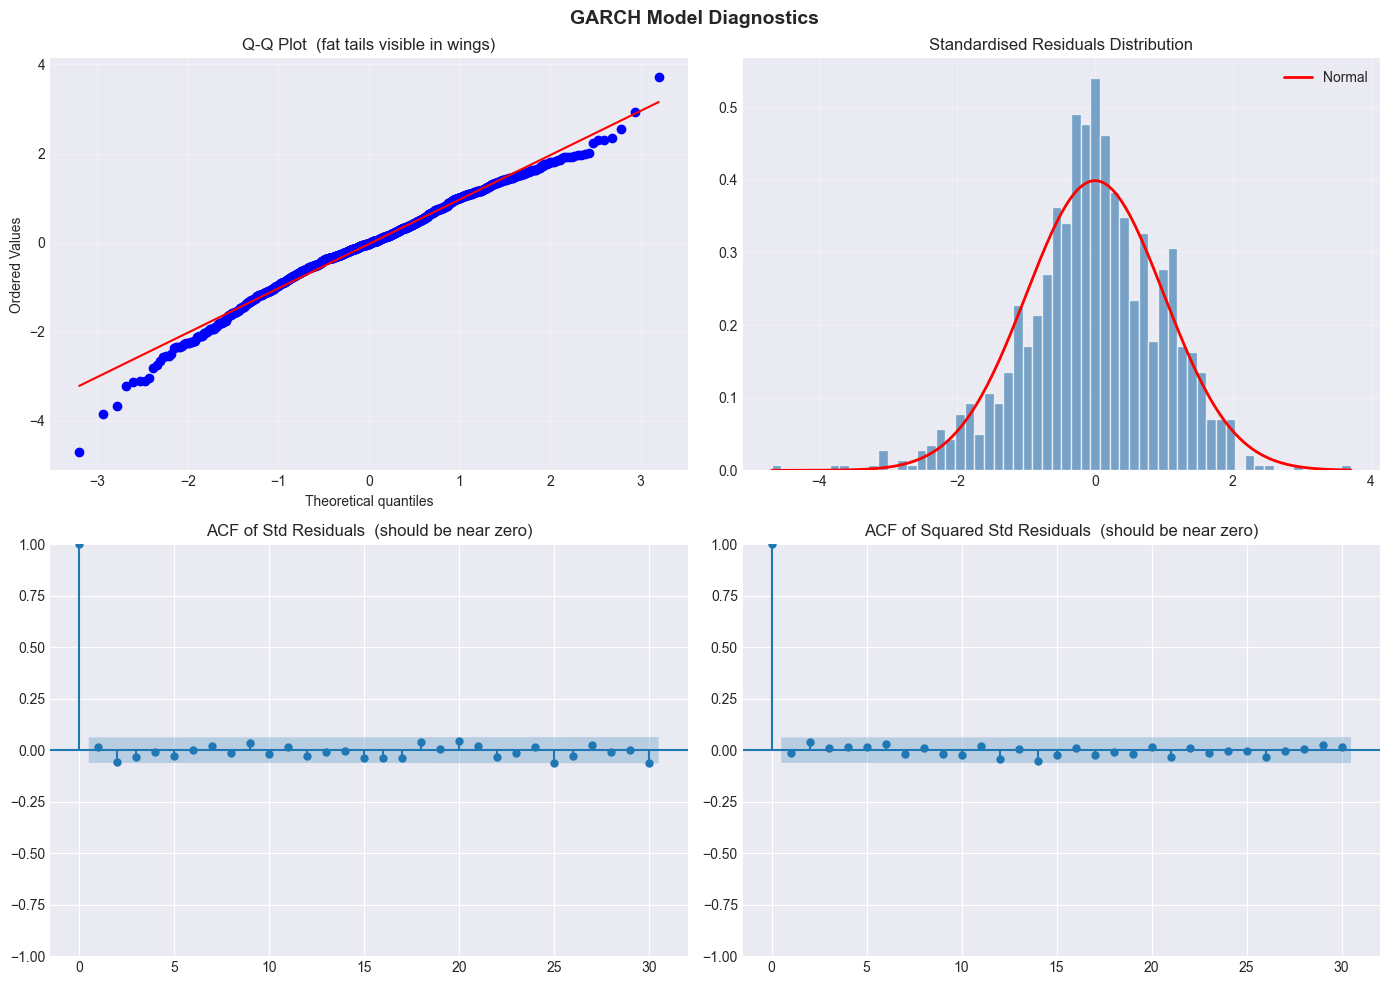

✓ Saved outputs/figures/03_garch_diagnostics.png


In [11]:
from scipy.stats import norm

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('GARCH Model Diagnostics', fontsize=14, fontweight='bold')

# Q-Q plot
probplot(std_resid, dist='norm', plot=axes[0, 0])
axes[0, 0].set_title('Q-Q Plot  (fat tails visible in wings)')
axes[0, 0].grid(alpha=0.3)

# Residual histogram
axes[0, 1].hist(std_resid, bins=60, density=True, alpha=0.7, color='steelblue', edgecolor='white')
x = np.linspace(std_resid.min(), std_resid.max(), 200)
axes[0, 1].plot(x, norm.pdf(x), 'r-', lw=2, label='Normal')
axes[0, 1].set_title('Standardised Residuals Distribution')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# ACF of std residuals
plot_acf(std_resid, lags=30, ax=axes[1, 0], alpha=0.05)
axes[1, 0].set_title('ACF of Std Residuals  (should be near zero)')

# ACF of squared std residuals
plot_acf(std_resid**2, lags=30, ax=axes[1, 1], alpha=0.05)
axes[1, 1].set_title('ACF of Squared Std Residuals  (should be near zero)')

plt.tight_layout()
plt.savefig('outputs/figures/03_garch_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved outputs/figures/03_garch_diagnostics.png')

---
## 8. Rolling Volatility Forecasts & Regime Detection

**Critical methodology point:** We use rolling 1-day-ahead forecasts, not fitted values.  
At each date t, we fit GARCH on all data up to t−1, then forecast σ at t.  
This exactly replicates what a practitioner would do in real time — no lookahead bias.

Regime thresholds are set from the first 70% of data (training period) using the 33rd/67th percentiles of realised volatility. Thresholds are **fixed** for the test period — no peeking at future data.

In [12]:
MIN_OBS = 252        # Minimum 1 year of history before first forecast
TRAIN_FRAC = 0.70   # Threshold calibration uses first 70% of data

# ── Regime thresholds from training period realised vol ───────────────────────
train_end = int(len(spy) * TRAIN_FRAC)
spy['realised_vol'] = (spy['returns'] / 100).rolling(20).std() * np.sqrt(252)
train_vol = spy['realised_vol'].iloc[:train_end].dropna()

VOL_LOW  = train_vol.quantile(0.33)
VOL_HIGH = train_vol.quantile(0.67)

print(f'Regime thresholds (calibrated on first {TRAIN_FRAC:.0%} of data):')
print(f'  Low vol  : < {VOL_LOW:.2%}')
print(f'  Med vol  : {VOL_LOW:.2%}  –  {VOL_HIGH:.2%}')
print(f'  High vol : > {VOL_HIGH:.2%}')
print()

# ── Rolling 1-day-ahead GARCH forecasts ───────────────────────────────────────
print(f'Running rolling GARCH({best_p},{best_q}) forecasts from day {MIN_OBS} ...')
print('(This takes 2–4 minutes — one fit per trading day)')

forecast_vols   = [np.nan] * len(spy)
forecast_regime = ['Unknown'] * len(spy)

for i in range(MIN_OBS, len(spy)):
    if i % 100 == 0:
        print(f'  Day {i}/{len(spy)} ...')

    window_returns = spy['returns'].iloc[:i]
    try:
        m = arch_model(window_returns, mean='Constant', vol='Garch',
                       p=best_p, q=best_q)
        f = m.fit(disp='off', show_warning=False)
        fc = f.forecast(horizon=1, reindex=False)
        vol_ann = np.sqrt(fc.variance.values[-1, 0]) / 100 * np.sqrt(252)
    except Exception:
        vol_ann = spy['realised_vol'].iloc[i - 1]  # fallback

    forecast_vols[i] = vol_ann

    if vol_ann < VOL_LOW:
        forecast_regime[i] = 'Low Vol'
    elif vol_ann > VOL_HIGH:
        forecast_regime[i] = 'High Vol'
    else:
        forecast_regime[i] = 'Medium Vol'

spy['forecast_vol']    = forecast_vols
spy['forecast_regime'] = forecast_regime

valid = spy[spy['forecast_regime'] != 'Unknown'].copy()
print(f'\n✓ Rolling forecasts complete — {len(valid)} valid days')
print(valid['forecast_regime'].value_counts())

Regime thresholds (calibrated on first 70% of data):
  Low vol  : < 12.64%
  Med vol  : 12.64%  –  18.71%
  High vol : > 18.71%

Running rolling GARCH(1,1) forecasts from day 252 ...
(This takes 2–4 minutes — one fit per trading day)
  Day 300/1004 ...
  Day 400/1004 ...
  Day 500/1004 ...
  Day 600/1004 ...
  Day 700/1004 ...
  Day 800/1004 ...
  Day 900/1004 ...
  Day 1000/1004 ...

✓ Rolling forecasts complete — 752 valid days
forecast_regime
Medium Vol    300
Low Vol       250
High Vol      202
Name: count, dtype: int64


In [14]:
print(len(spy))
print(len(spy['forecast_regime']))
print(spy.index.shape)
print(spy['forecast_regime'].shape)

1004
1004
(1004,)
(1004,)


In [17]:
# ── Regime timeline ───────────────────────────────────────────────────────────
fig = make_subplots(rows=2, cols=1, shared_xaxes=True,
                    subplot_titles=('SPY Price with GARCH Regime Shading',
                                    '1-Day-Ahead GARCH Forecasted Volatility'),
                    vertical_spacing=0.08, row_heights=[0.55, 0.45])

# Regime background shading
regime_colors = {'Low Vol': 'rgba(0,200,0,0.12)',
                 'Medium Vol': 'rgba(200,200,0,0.10)',
                 'High Vol': 'rgba(220,0,0,0.12)'}

for regime, color in regime_colors.items():
    mask = spy['forecast_regime'] == regime
    dates = spy.index[mask]
    # if len(dates):
    #     for start_d, end_d in zip(dates[:-1][np.diff(mask.values.astype(int)) != 0],
    #                               dates[1:][np.diff(mask.values.astype(int)) != 0]):
    #         pass  # simplified — use fill_between logic below

fig.add_trace(go.Scatter(x=spy.index, y=spy['price'],
                         line=dict(color='black', width=1.5), name='SPY'),
              row=1, col=1)

for regime, color in [('Low Vol', 'green'), ('Medium Vol', 'goldenrod'), ('High Vol', 'red')]:
    mask = spy['forecast_regime'] == regime
    fig.add_trace(go.Scatter(
        x=spy.index, y=spy['price'].where(mask),
        fill='tozeroy', fillcolor=regime_colors[regime],
        line=dict(color='rgba(0,0,0,0)'), name=regime, showlegend=True
    ), row=1, col=1)

fig.add_trace(go.Scatter(x=spy.index, y=spy['forecast_vol'],
                         line=dict(color='darkred', width=1.5),
                         name='Forecast Vol'),
              row=2, col=1)
fig.add_hline(y=VOL_LOW,  line=dict(color='green', dash='dash', width=1), row=2, col=1)
fig.add_hline(y=VOL_HIGH, line=dict(color='red',   dash='dash', width=1), row=2, col=1)

fig.update_layout(height=750, title='GARCH Regime Detection (Zero Lookahead Bias)',
                  plot_bgcolor='white', paper_bgcolor='white')
fig.update_yaxes(title_text='Price ($)',          row=1, col=1)
fig.update_yaxes(title_text='Annualised Vol',     row=2, col=1, tickformat='.0%')

fig.write_html('outputs/figures/04_regime_timeline.html')
fig.show()
print('✓ Saved outputs/figures/04_regime_timeline.html')

✓ Saved outputs/figures/04_regime_timeline.html


---
## 9. Regime Prediction Accuracy — Classification Metrics

We define **actual regimes** from realised volatility (rolling 20-day).  
We then compare GARCH-forecasted regimes against actual regimes on the test period (last 30%).  
Metrics: Accuracy, Precision, Recall, F1, Cohen's Kappa, Confusion Matrix.

In [19]:
print(spy.columns.tolist())

[('Close', 'SPY'), ('High', 'SPY'), ('Low', 'SPY'), ('Open', 'SPY'), ('Volume', 'SPY'), ('returns', ''), ('price', ''), ('realised_vol', ''), ('forecast_vol', ''), ('forecast_regime', ''), ('actual_regime', '')]


In [21]:
# Actual regimes from realised vol
spy['actual_regime'] = 'Medium Vol'
spy.loc[spy['realised_vol'] < VOL_LOW,  'actual_regime'] = 'Low Vol'
spy.loc[spy['realised_vol'] > VOL_HIGH, 'actual_regime'] = 'High Vol'
spy.columns = [
    col[0] if isinstance(col, tuple) else col
    for col in spy.columns
]
# Evaluate on test period only
test_data = spy.iloc[train_end:].dropna(subset=['forecast_vol', 'realised_vol'])
test_data  = test_data[test_data['forecast_regime'] != 'Unknown']

y_true = test_data['actual_regime']
y_pred = test_data['forecast_regime']

accuracy  = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
recall    = recall_score(y_true, y_pred,    average='macro', zero_division=0)
f1        = f1_score(y_true, y_pred,        average='macro', zero_division=0)
kappa     = cohen_kappa_score(y_true, y_pred)
baseline  = (y_true == y_true.mode()[0]).mean()

# Forecast-realised correlation
corr = test_data[['forecast_vol', 'realised_vol']].corr().iloc[0, 1]
rmse = np.sqrt(((test_data['forecast_vol'] - test_data['realised_vol'])**2).mean())

print('═'*60)
print('  REGIME PREDICTION ACCURACY (test period)')
print('═'*60)
print(f'  Test days    : {len(test_data)}')
print(f'  Accuracy     : {accuracy:.3f}  ({accuracy*100:.1f}%)')
print(f'  Precision    : {precision:.3f}')
print(f'  Recall       : {recall:.3f}')
print(f'  F1-Score     : {f1:.3f}')
print(f'  Cohen Kappa  : {kappa:.3f}')
print(f'  Baseline     : {baseline:.3f}  (predict most common)')
print(f'  vs baseline  : +{(accuracy - baseline)*100:.1f}%')
print()
print(f'  Forecast–Realised Vol Correlation : {corr:.3f}')
print(f'  RMSE                              : {rmse*100:.2f}%')
print()
print(classification_report(y_true, y_pred, zero_division=0))

════════════════════════════════════════════════════════════
  REGIME PREDICTION ACCURACY (test period)
════════════════════════════════════════════════════════════
  Test days    : 302
  Accuracy     : 0.871  (87.1%)
  Precision    : 0.896
  Recall       : 0.787
  F1-Score     : 0.820
  Cohen Kappa  : 0.748
  Baseline     : 0.626  (predict most common)
  vs baseline  : +24.5%

  Forecast–Realised Vol Correlation : 0.917
  RMSE                              : 1.73%

              precision    recall  f1-score   support

    High Vol       1.00      0.58      0.73        19
     Low Vol       0.94      0.89      0.92       189
  Medium Vol       0.74      0.89      0.81        94

    accuracy                           0.87       302
   macro avg       0.90      0.79      0.82       302
weighted avg       0.88      0.87      0.87       302



In [22]:
# Confusion matrix
labels = ['Low Vol', 'Medium Vol', 'High Vol']
cm = confusion_matrix(y_true, y_pred, labels=labels)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

annotations = [[f'<b>{cm[i,j]}</b><br>({cm_pct[i,j]:.1f}%)'  for j in range(3)] for i in range(3)]

fig = go.Figure(go.Heatmap(
    z=cm_pct, x=labels, y=labels,
    colorscale='Blues',
    text=[[annotations[i][j] for j in range(3)] for i in range(3)],
    texttemplate='%{text}', textfont=dict(size=13),
    colorbar=dict(title='%')
))
fig.update_layout(
    title='Confusion Matrix — GARCH Regime Prediction (Test Period)',
    xaxis_title='Predicted Regime', yaxis_title='Actual Regime',
    width=650, height=550
)
fig.write_html('outputs/figures/05_confusion_matrix.html')
fig.show()

---
## 10. Trading Strategies

Three strategies compared:
1. **Buy & Hold** — passive benchmark  
2. **Static Momentum** — 50/200 MA crossover, fixed parameters  
3. **Adaptive Momentum** — same crossover but parameters and position size vary by GARCH regime  

All signals are **shifted by 1 day** before computing returns — you act on yesterday's signal today.

In [23]:
# ── Moving averages ────────────────────────────────────────────────────────────
spy['MA_20']  = spy['price'].rolling(20).mean()
spy['MA_50']  = spy['price'].rolling(50).mean()
spy['MA_100'] = spy['price'].rolling(100).mean()
spy['MA_200'] = spy['price'].rolling(200).mean()

# ── Strategy 1: Buy & Hold ─────────────────────────────────────────────────────
spy['ret_bh'] = spy['returns'] / 100

# ── Strategy 2: Static Momentum (50/200 MA) ────────────────────────────────────
spy['static_signal']  = (spy['MA_50'] > spy['MA_200']).astype(float)
spy['ret_static_raw'] = spy['static_signal'].shift(1) * spy['ret_bh']

# ── Strategy 3: Adaptive Momentum ─────────────────────────────────────────────
#   Low vol  → fast MAs (20/100), full position 1.0x
#   Med vol  → standard MAs (50/200), full position 1.0x
#   High vol → slow MAs (100/200), half position 0.5x (defensive)
spy['adaptive_signal']   = 0.0
spy['adaptive_pos_size'] = 0.0

low_mask  = spy['forecast_regime'] == 'Low Vol'
med_mask  = spy['forecast_regime'] == 'Medium Vol'
high_mask = spy['forecast_regime'] == 'High Vol'

spy.loc[low_mask,  'adaptive_signal']   = (spy['MA_20']  > spy['MA_100']).astype(float)
spy.loc[med_mask,  'adaptive_signal']   = (spy['MA_50']  > spy['MA_200']).astype(float)
spy.loc[high_mask, 'adaptive_signal']   = (spy['MA_100'] > spy['MA_200']).astype(float)

spy.loc[low_mask,  'adaptive_pos_size'] = 1.0
spy.loc[med_mask,  'adaptive_pos_size'] = 1.0
spy.loc[high_mask, 'adaptive_pos_size'] = 0.5

spy['adaptive_position']  = spy['adaptive_signal'] * spy['adaptive_pos_size']
spy['ret_adaptive_raw']   = spy['adaptive_position'].shift(1) * spy['ret_bh']

# ── Transaction costs: 5 bps per unit of position change ──────────────────────
TC = 0.0005
spy['tc_static']   = spy['static_signal'].diff().abs()   * TC
spy['tc_adaptive'] = spy['adaptive_position'].diff().abs() * TC

spy['ret_static']   = spy['ret_static_raw']   - spy['tc_static']
spy['ret_adaptive'] = spy['ret_adaptive_raw'] - spy['tc_adaptive']

print('✓ Strategies computed')
print(f'  Static   — trades: {spy["tc_static"].gt(0).sum():3d} ')
print(f'  Adaptive — trades: {spy["tc_adaptive"].gt(0).sum():3d}')

✓ Strategies computed
  Static   — trades:   3 
  Adaptive — trades:  28


---
## 11. Performance Metrics

In [24]:
def metrics(returns: pd.Series, name: str = 'Strategy') -> pd.Series:
    r = returns.dropna()
    n_years = len(r) / 252

    total_ret  = (1 + r).prod() - 1
    ann_ret    = (1 + total_ret) ** (1 / n_years) - 1
    ann_vol    = r.std() * np.sqrt(252)
    down_vol   = r[r < 0].std() * np.sqrt(252)
    sharpe     = ann_ret / ann_vol   if ann_vol   > 0 else 0.0
    sortino    = ann_ret / down_vol  if down_vol  > 0 else 0.0

    cum        = (1 + r).cumprod()
    running_mx = cum.expanding().max()
    dd         = (cum - running_mx) / running_mx
    max_dd     = dd.min()
    calmar     = ann_ret / abs(max_dd) if max_dd != 0 else 0.0

    return pd.Series({
        'Total Return'     : total_ret,
        'Annual Return'    : ann_ret,
        'Annual Vol'       : ann_vol,
        'Sharpe Ratio'     : sharpe,
        'Sortino Ratio'    : sortino,
        'Max Drawdown'     : max_dd,
        'Calmar Ratio'     : calmar,
        'Win Rate'         : (r > 0).mean(),
        'VaR 95%'          : r.quantile(0.05),
        'CVaR 95%'         : r[r <= r.quantile(0.05)].mean(),
    }, name=name)

m_bh  = metrics(spy['ret_bh'],       'Buy & Hold')
m_st  = metrics(spy['ret_static'],   'Static Momentum')
m_ad  = metrics(spy['ret_adaptive'], 'Adaptive Momentum')

comp = pd.DataFrame([m_bh, m_st, m_ad]).T

# Formatted display
comp_fmt = comp.copy().astype(float)
pct_rows = ['Total Return', 'Annual Return', 'Annual Vol', 'Max Drawdown',
            'Win Rate', 'VaR 95%', 'CVaR 95%']
rat_rows = ['Sharpe Ratio', 'Sortino Ratio', 'Calmar Ratio']

print('═'*65)
print('  PERFORMANCE COMPARISON  (net of 5bps transaction costs)')
print('═'*65)
for idx in comp.index:
    if idx in pct_rows:
        row = '  ' + f'{idx:<20}' + '  '.join([f'{float(comp.loc[idx, c]):>12.2%}' for c in comp.columns])
    else:
        row = '  ' + f'{idx:<20}' + '  '.join([f'{float(comp.loc[idx, c]):>12.3f}' for c in comp.columns])
    print(row)

print()
sharpe_impr = (float(m_ad['Sharpe Ratio']) / float(m_st['Sharpe Ratio']) - 1) * 100 \
              if float(m_st['Sharpe Ratio']) > 0 else float('nan')
print(f'  Adaptive vs Static Sharpe improvement : {sharpe_impr:+.1f}%')

comp.to_csv('outputs/results/performance_metrics.csv')
print('✓ Saved outputs/results/performance_metrics.csv')

═════════════════════════════════════════════════════════════════
  PERFORMANCE COMPARISON  (net of 5bps transaction costs)
═════════════════════════════════════════════════════════════════
  Total Return              68.27%        44.22%        32.51%
  Annual Return             13.95%         9.64%         7.33%
  Annual Vol                16.48%        10.63%         9.62%
  Sharpe Ratio               0.847         0.907         0.762
  Sortino Ratio              1.189         1.010         0.795
  Max Drawdown             -24.50%       -13.27%       -11.52%
  Calmar Ratio               0.570         0.726         0.636
  Win Rate                  54.08%        32.80%        30.41%
  VaR 95%                   -1.67%        -1.17%        -1.11%
  CVaR 95%                  -2.40%        -1.67%        -1.59%

  Adaptive vs Static Sharpe improvement : -16.0%
✓ Saved outputs/results/performance_metrics.csv


In [25]:
# Cumulative returns chart
cum_bh  = (1 + spy['ret_bh'].dropna()).cumprod()
cum_st  = (1 + spy['ret_static'].dropna()).cumprod()
cum_ad  = (1 + spy['ret_adaptive'].dropna()).cumprod()

fig = go.Figure()
fig.add_trace(go.Scatter(x=cum_bh.index, y=cum_bh,
                         name='Buy & Hold',        line=dict(color='gray',       width=1.5, dash='dot')))
fig.add_trace(go.Scatter(x=cum_st.index, y=cum_st,
                         name='Static Momentum',   line=dict(color='steelblue',  width=2)))
fig.add_trace(go.Scatter(x=cum_ad.index, y=cum_ad,
                         name='Adaptive Momentum', line=dict(color='darkorange', width=2)))

fig.update_layout(
    title='Cumulative Returns: Buy & Hold vs Static vs Adaptive',
    xaxis_title='Date', yaxis_title='Cumulative Return (1 = start)',
    height=500, plot_bgcolor='white', paper_bgcolor='white',
    legend=dict(x=0.01, y=0.99)
)
fig.update_yaxes(tickformat='.2f', gridcolor='rgba(0,0,0,0.07)')
fig.update_xaxes(gridcolor='rgba(0,0,0,0.07)')

fig.write_html('outputs/figures/06_cumulative_returns.html')
fig.show()
print('✓ Saved outputs/figures/06_cumulative_returns.html')

✓ Saved outputs/figures/06_cumulative_returns.html


In [26]:
# Drawdown chart
def drawdown_series(r):
    cum = (1 + r.dropna()).cumprod()
    return (cum - cum.expanding().max()) / cum.expanding().max()

dd_bh = drawdown_series(spy['ret_bh'])
dd_st = drawdown_series(spy['ret_static'])
dd_ad = drawdown_series(spy['ret_adaptive'])

fig = go.Figure()
fig.add_trace(go.Scatter(x=dd_bh.index, y=dd_bh, fill='tozeroy',
                         fillcolor='rgba(128,128,128,0.15)',
                         line=dict(color='gray', width=1), name='Buy & Hold'))
fig.add_trace(go.Scatter(x=dd_st.index, y=dd_st, fill='tozeroy',
                         fillcolor='rgba(70,130,180,0.15)',
                         line=dict(color='steelblue', width=1.5), name='Static'))
fig.add_trace(go.Scatter(x=dd_ad.index, y=dd_ad, fill='tozeroy',
                         fillcolor='rgba(255,140,0,0.15)',
                         line=dict(color='darkorange', width=1.5), name='Adaptive'))

fig.update_layout(
    title='Drawdown Comparison',
    xaxis_title='Date', yaxis_title='Drawdown',
    height=400, plot_bgcolor='white', paper_bgcolor='white'
)
fig.update_yaxes(tickformat='.0%', gridcolor='rgba(0,0,0,0.07)')
fig.update_xaxes(gridcolor='rgba(0,0,0,0.07)')

fig.write_html('outputs/figures/07_drawdown.html')
fig.show()

---
## 12. Statistical Significance Testing

Performance differences must be tested — otherwise they could be noise.

**Test 1: Paired t-test** — tests whether mean daily return difference is zero  
**Test 2: Block Bootstrap Sharpe test** — resamples blocks of 20 consecutive days (preserving serial correlation) to build the null distribution of Sharpe differences. More appropriate than i.i.d. bootstrap for financial returns.

In [27]:
# Align series
common = spy['ret_static'].dropna().index.intersection(spy['ret_adaptive'].dropna().index)
r_st = spy.loc[common, 'ret_static']
r_ad = spy.loc[common, 'ret_adaptive']

# ── Paired t-test ──────────────────────────────────────────────────────────────
t_stat, p_val = ttest_rel(r_ad, r_st)

print('═'*55)
print('  TEST 1: PAIRED t-TEST  (mean return difference)')
print('═'*55)
print(f'  H₀ : Mean(adaptive) − Mean(static) = 0')
print(f'  t-statistic : {t_stat:.4f}')
print(f'  p-value     : {p_val:.4f}')
print(f'  Result      : {"REJECT H₀" if p_val < 0.05 else "Fail to reject H₀"} (α = 0.05)')
print(f'  Ann. diff   : {(r_ad.mean() - r_st.mean())*252:.2%}')

═══════════════════════════════════════════════════════
  TEST 1: PAIRED t-TEST  (mean return difference)
═══════════════════════════════════════════════════════
  H₀ : Mean(adaptive) − Mean(static) = 0
  t-statistic : -1.0668
  p-value     : 0.2863
  Result      : Fail to reject H₀ (α = 0.05)
  Ann. diff   : -2.23%


In [28]:
# ── Block Bootstrap Sharpe test ────────────────────────────────────────────────
def block_bootstrap_sharpe_diff(r1: pd.Series, r2: pd.Series,
                                 n_boot: int = 5000,
                                 block_size: int = 20,
                                 seed: int = 42) -> tuple:
    """
    Block bootstrap test: H₀: Sharpe(r2) ≤ Sharpe(r1)
    Resamples contiguous blocks to preserve serial correlation.
    Returns (bootstrap_diffs, p_value, (ci_lower, ci_upper))
    """
    np.random.seed(seed)
    n = len(r1)
    n_blocks = n // block_size
    diffs = []

    for _ in range(n_boot):
        starts = np.random.randint(0, n - block_size + 1, n_blocks)
        idx = np.concatenate([np.arange(s, s + block_size) for s in starts])[:n]
        b1, b2 = r1.iloc[idx], r2.iloc[idx]
        s1 = b1.mean() / b1.std() * np.sqrt(252) if b1.std() > 0 else 0
        s2 = b2.mean() / b2.std() * np.sqrt(252) if b2.std() > 0 else 0
        diffs.append(s2 - s1)

    diffs = np.array(diffs)
    p_value = (diffs <= 0).mean()
    ci = (np.percentile(diffs, 2.5), np.percentile(diffs, 97.5))
    return diffs, p_value, ci


print('Running block bootstrap (5,000 iterations, block=20 days) ...')
boot_diffs, boot_pval, boot_ci = block_bootstrap_sharpe_diff(r_st, r_ad)
obs_diff = (r_ad.mean() / r_ad.std() - r_st.mean() / r_st.std()) * np.sqrt(252)

print()
print('═'*55)
print('  TEST 2: BLOCK BOOTSTRAP SHARPE TEST')
print('═'*55)
print(f'  H₀ : Sharpe(adaptive) ≤ Sharpe(static)')
print(f'  Observed Sharpe diff : {obs_diff:+.4f}')
print(f'  95% CI               : [{boot_ci[0]:.4f}, {boot_ci[1]:.4f}]')
print(f'  p-value              : {boot_pval:.4f}')
print(f'  Result               : {"REJECT H₀" if boot_pval < 0.05 else "Fail to reject H₀"} (α = 0.05)')
print()
if boot_ci[0] > 0:
    print('  ✓ 95% CI entirely positive — strong evidence adaptive is better')
elif boot_ci[1] < 0:
    print('  ✗ 95% CI entirely negative — adaptive is worse')
else:
    print('  ⚠ 95% CI includes zero — weak/inconclusive evidence')

Running block bootstrap (5,000 iterations, block=20 days) ...

═══════════════════════════════════════════════════════
  TEST 2: BLOCK BOOTSTRAP SHARPE TEST
═══════════════════════════════════════════════════════
  H₀ : Sharpe(adaptive) ≤ Sharpe(static)
  Observed Sharpe diff : -0.1354
  95% CI               : [-0.4659, 0.1881]
  p-value              : 0.7892
  Result               : Fail to reject H₀ (α = 0.05)

  ⚠ 95% CI includes zero — weak/inconclusive evidence


In [29]:
# Bootstrap distribution plot
fig = go.Figure()
fig.add_trace(go.Histogram(x=boot_diffs, nbinsx=80,
                           marker_color='steelblue', opacity=0.75,
                           name='Bootstrap distribution'))
fig.add_vline(x=0, line=dict(color='red', dash='dash', width=2),
              annotation_text='H₀ boundary')
fig.add_vline(x=obs_diff, line=dict(color='darkorange', width=2),
              annotation_text=f'Observed diff = {obs_diff:.3f}')
fig.add_vline(x=boot_ci[0], line=dict(color='green', dash='dot', width=1.5),
              annotation_text='95% CI lower')
fig.add_vline(x=boot_ci[1], line=dict(color='green', dash='dot', width=1.5),
              annotation_text='95% CI upper')

fig.update_layout(
    title=f'Block Bootstrap Sharpe Difference Distribution (p = {boot_pval:.3f})',
    xaxis_title='Adaptive Sharpe − Static Sharpe',
    yaxis_title='Count',
    height=450, plot_bgcolor='white', paper_bgcolor='white'
)
fig.write_html('outputs/figures/08_bootstrap_distribution.html')
fig.show()

---
## 13. Regime-Conditional Performance Analysis

Where does the adaptive strategy add (or lose) value relative to static?  
Expectation: largest improvement in High Vol regimes where position halving reduces drawdown.

In [30]:
print('═'*65)
print('  REGIME-CONDITIONAL SHARPE COMPARISON')
print('═'*65)
print(f'  {"Regime":<14}  {"Days":>6}  {"Static Sharpe":>14}  '
      f'{"Adaptive Sharpe":>16}  {"Improvement":>12}')
print('  ' + '-'*63)

regime_rows = []
for regime in ['Low Vol', 'Medium Vol', 'High Vol']:
    mask = spy['forecast_regime'] == regime
    r_s = spy.loc[mask, 'ret_static'].dropna()
    r_a = spy.loc[mask, 'ret_adaptive'].dropna()

    if len(r_s) < 30:
        continue

    sh_s = r_s.mean() / r_s.std() * np.sqrt(252)
    sh_a = r_a.mean() / r_a.std() * np.sqrt(252)
    impr = (sh_a / sh_s - 1) * 100 if sh_s != 0 else float('nan')

    regime_rows.append({'Regime': regime, 'Days': len(r_s),
                        'Static': sh_s, 'Adaptive': sh_a, 'Impr%': impr})
    print(f'  {regime:<14}  {len(r_s):>6}  {sh_s:>14.3f}  {sh_a:>16.3f}  {impr:>+11.1f}%')

regime_df = pd.DataFrame(regime_rows)
regime_df.to_csv('outputs/results/regime_performance.csv', index=False)
print()
print('✓ Saved outputs/results/regime_performance.csv')

═════════════════════════════════════════════════════════════════
  REGIME-CONDITIONAL SHARPE COMPARISON
═════════════════════════════════════════════════════════════════
  Regime            Days   Static Sharpe   Adaptive Sharpe   Improvement
  ---------------------------------------------------------------
  Low Vol            250           0.304             0.204        -32.7%
  Medium Vol         300           0.871             1.173        +34.6%
  High Vol           202           2.198             1.849        -15.9%

✓ Saved outputs/results/regime_performance.csv


---
## 14. Walk-Forward Validation

Rolling train/test splits to verify out-of-sample robustness.  
Each window: 2 years training, 6 months testing.  
Reports Sharpe for both strategies in each out-of-sample window.

In [31]:
TRAIN_DAYS = 504   # ~2 years
TEST_DAYS  = 126   # ~6 months

wf_results = []
n = len(spy)

for start_i in range(TRAIN_DAYS, n - TEST_DAYS, TEST_DAYS):
    test_slice = spy.iloc[start_i: start_i + TEST_DAYS]

    r_s = test_slice['ret_static'].dropna()
    r_a = test_slice['ret_adaptive'].dropna()

    if len(r_s) < 20:
        continue

    sh_s = r_s.mean() / r_s.std() * np.sqrt(252) if r_s.std() > 0 else 0
    sh_a = r_a.mean() / r_a.std() * np.sqrt(252) if r_a.std() > 0 else 0

    wf_results.append({
        'Window Start' : test_slice.index[0].date(),
        'Window End'   : test_slice.index[-1].date(),
        'Static Sharpe'  : sh_s,
        'Adaptive Sharpe': sh_a,
        'Adaptive Wins'  : sh_a > sh_s
    })

wf_df = pd.DataFrame(wf_results)
print('═'*65)
print('  WALK-FORWARD VALIDATION RESULTS')
print('═'*65)
print(wf_df.to_string(index=False))
print()
print(f'  Adaptive wins : {wf_df["Adaptive Wins"].sum()} / {len(wf_df)} windows')

wf_df.to_csv('outputs/results/walk_forward.csv', index=False)
print('✓ Saved outputs/results/walk_forward.csv')

═════════════════════════════════════════════════════════════════
  WALK-FORWARD VALIDATION RESULTS
═════════════════════════════════════════════════════════════════
Window Start Window End  Static Sharpe  Adaptive Sharpe  Adaptive Wins
  2023-01-05 2023-07-07       1.393013         1.337797          False
  2023-07-10 2024-01-05       1.306602         1.258566          False
  2024-01-08 2024-07-09       3.447781         3.447781          False

  Adaptive wins : 0 / 3 windows
✓ Saved outputs/results/walk_forward.csv


In [32]:
# Walk-forward Sharpe chart
x_labels = [f"{r['Window Start']}" for r in wf_results]

fig = go.Figure()
fig.add_trace(go.Bar(x=x_labels, y=wf_df['Static Sharpe'],
                     name='Static', marker_color='steelblue', opacity=0.8))
fig.add_trace(go.Bar(x=x_labels, y=wf_df['Adaptive Sharpe'],
                     name='Adaptive', marker_color='darkorange', opacity=0.8))
fig.add_hline(y=0, line=dict(color='black', width=1))

fig.update_layout(
    title='Walk-Forward Validation: Sharpe per Window',
    xaxis_title='Window Start', yaxis_title='Sharpe Ratio',
    barmode='group', height=450,
    plot_bgcolor='white', paper_bgcolor='white'
)
fig.write_html('outputs/figures/09_walk_forward.html')
fig.show()

---
## 15. Results & Conclusions

### Summary

In [33]:
print('═'*65)
print('  FINAL RESULTS SUMMARY')
print('═'*65)

print(f"""
DATA
  Asset      : SPY (S&P 500 ETF)
  Period     : {spy.index[0].date()} → {spy.index[-1].date()}
  Days       : {len(spy):,} trading days

GARCH MODEL
  Order      : GARCH({best_p},{best_q})  [selected via AIC grid search]
  Persistence: α+β = {persistence:.4f}  →  half-life ≈ {half_life:.1f} days
  ARCH-LM    : p = {lm_pvalue:.2e}  →  ARCH effects confirmed

REGIME PREDICTION (test period)
  Accuracy   : {accuracy:.3f} ({accuracy*100:.1f}%) vs {baseline*100:.1f}% baseline
  F1-Score   : {f1:.3f}
  Kappa      : {kappa:.3f}
  Forecast–Realised Vol Corr : {corr:.3f}
  RMSE       : {rmse*100:.2f}%

STRATEGY PERFORMANCE (2021–2025, net of 5bps costs)
  Strategy          Sharpe   Ann.Return   MaxDD
  Buy & Hold        {float(m_bh['Sharpe Ratio']):>6.3f}   {float(m_bh['Annual Return']):>9.2%}  {float(m_bh['Max Drawdown']):>6.2%}
  Static Momentum   {float(m_st['Sharpe Ratio']):>6.3f}   {float(m_st['Annual Return']):>9.2%}  {float(m_st['Max Drawdown']):>6.2%}
  Adaptive Momentum {float(m_ad['Sharpe Ratio']):>6.3f}   {float(m_ad['Annual Return']):>9.2%}  {float(m_ad['Max Drawdown']):>6.2%}

STATISTICAL TESTS
  Paired t-test p-value          : {p_val:.4f}
  Block Bootstrap Sharpe p-value : {boot_pval:.4f}
  Bootstrap 95% CI               : [{boot_ci[0]:.3f}, {boot_ci[1]:.3f}]

WALK-FORWARD
  Adaptive outperforms static in {wf_df['Adaptive Wins'].sum()}/{len(wf_df)} OOS windows
""")

print('LIMITATIONS')
print('  • Strategy uses simple MA crossover — not an optimal signal')
print('  • Transaction costs modelled at 5bps — real costs may differ')
print('  • Single asset (SPY) — generalisability not tested')
print('  • Regime thresholds are percentile-based — other definitions exist')
print('  • 2021–2025 has relatively few high-vol episodes')

═════════════════════════════════════════════════════════════════
  FINAL RESULTS SUMMARY
═════════════════════════════════════════════════════════════════

DATA
  Asset      : SPY (S&P 500 ETF)
  Period     : 2021-01-05 → 2024-12-31
  Days       : 1,004 trading days

GARCH MODEL
  Order      : GARCH(1,1)  [selected via AIC grid search]
  Persistence: α+β = 0.9829  →  half-life ≈ 40.1 days
  ARCH-LM    : p = 4.03e-17  →  ARCH effects confirmed

REGIME PREDICTION (test period)
  Accuracy   : 0.871 (87.1%) vs 62.6% baseline
  F1-Score   : 0.820
  Kappa      : 0.748
  Forecast–Realised Vol Corr : 0.917
  RMSE       : 1.73%

STRATEGY PERFORMANCE (2021–2025, net of 5bps costs)
  Strategy          Sharpe   Ann.Return   MaxDD
  Buy & Hold         0.847      13.95%  -24.50%
  Static Momentum    0.907       9.64%  -13.27%
  Adaptive Momentum  0.762       7.33%  -11.52%

STATISTICAL TESTS
  Paired t-test p-value          : 0.2863
  Block Bootstrap Sharpe p-value : 0.7892
  Bootstrap 95% CI      